# Warehouse Navigation — Markov Decision Process (MDP)

## Problem Description

A robot operates inside a **warehouse** represented as a discrete grid.
There are **N packages** scattered around the warehouse, each with a designated **storage location**.
The robot must:

1. Navigate around obstacles
2. Pick up packages **one at a time**
3. Deliver each package to its designated storage

We model this as a **Markov Decision Process (MDP)** — a mathematical framework for sequential
decision-making — so we can later apply reinforcement learning algorithms (Q-Learning, SARSA,
Value Iteration, Policy Iteration, DQN) to find the optimal delivery strategy.

---

## MDP Framework

An MDP is a tuple **(S, A, T, R)**:

| Symbol | Component | Description |
|--------|-----------|-------------|
| **S** | State space | Every possible configuration the robot can be in |
| **A** | Action space | All moves and interactions available to the robot |
| **T(s, a) → s'** | Transition function | How the environment changes after an action |
| **R(s, a)** | Reward function | Numerical feedback guiding the agent toward the goal |

The agent's objective is to find a **policy** π: S → A that maximises the total cumulative reward.

---
## 1. The Warehouse Grid

We use a **4 × 4 grid** as our warehouse.

| Symbol | Meaning |
|--------|---------|
| `R` | Robot start position |
| `P0`, `P1` | Package pickup locations |
| `D0`, `D1` | Storage / delivery locations (package `i` → storage `i`) |
| `#` | Obstacle — the robot cannot enter this cell |
| `.` | Empty passable cell |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle
from dataclasses import dataclass
from typing import Optional, Tuple
from enum import Enum

# ── Warehouse grid ─────────────────────────────────────────────────────
ROWS, COLS    = 4, 4
NUM_PACKAGES  = 2

# 0 = passable,  1 = obstacle
GRID = np.array([
    [0, 0, 0, 0],   # row 0
    [0, 1, 0, 0],   # row 1  ← obstacle at (1, 1)
    [0, 0, 0, 0],   # row 2
    [0, 0, 0, 0],   # row 3
])

PACKAGE_LOCATIONS = {0: (0, 1), 1: (3, 3)}  # package_id -> (row, col)
STORAGE_LOCATIONS = {0: (3, 0), 1: (3, 2)}  # package_id -> (row, col)
START_POS = (0, 0)

# ── ASCII map ──────────────────────────────────────────────────────────
labels = [['.' if GRID[r, c] == 0 else '#' for c in range(COLS)] for r in range(ROWS)]
labels[START_POS[0]][START_POS[1]] = 'R'
for pid, (r, c) in PACKAGE_LOCATIONS.items():
    labels[r][c] = f'P{pid}'
for pid, (r, c) in STORAGE_LOCATIONS.items():
    labels[r][c] = f'D{pid}'

print('Warehouse layout (R=robot, P=package, D=storage, #=obstacle):')
print()
print('        col0  col1  col2  col3')
for r, row in enumerate(labels):
    print(f'  row {r}:  ' + '   '.join(f'{cell:2}' for cell in row))
print()
print(f'Passable cells : {int((GRID == 0).sum())}')
print(f'Obstacles      : {int((GRID == 1).sum())}')

Warehouse layout (R=robot, P=package, D=storage, #=obstacle):

        col0  col1  col2  col3
  row 0:  R    P0   .    . 
  row 1:  .    #    .    . 
  row 2:  .    .    .    . 
  row 3:  D0   .    D1   P1

Passable cells : 15
Obstacles      : 1


---
## 2. State Space  `S`

A **state** captures everything the agent needs to make a decision:

```
s = (robot_pos, carrying, delivered)
```

| Field | Type | Description |
|-------|------|-------------|
| `robot_pos` | `(row, col)` | Current position of the robot on the grid |
| `carrying` | `None` or `int` | ID of the package the robot is holding, or `None` |
| `delivered` | `tuple[bool, ...]` | One flag per package — `True` once it is delivered |

The state is **Markovian**: the next state depends only on the current state and action,
not on any past history.

### State space size

```
|S| = P × (N + 1) × 2^N
```

- **P** — number of passable cells the robot can occupy  
- **(N + 1)** — carrying states: `None`, pkg 0, pkg 1, …  
- **2^N** — all combinations of delivered / not-delivered flags

For our 4 × 4 grid (15 passable cells) with N = 2 packages:

```
|S| = 15 × 3 × 4 = 180 states
```

In [3]:
@dataclass(frozen=True)
class State:
    robot_pos : Tuple[int, int]
    carrying  : Optional[int]       # None = not carrying; int = package id
    delivered : Tuple[bool, ...]    # one bool per package

    def __repr__(self):
        carry = f'pkg{self.carrying}' if self.carrying is not None else 'none'
        deliv = ''.join('T' if d else 'F' for d in self.delivered)
        return f'State(pos={self.robot_pos}, carrying={carry}, delivered=[{deliv}])'


# ── State space size ───────────────────────────────────────────────────
passable      = int((GRID == 0).sum())
n_carry       = NUM_PACKAGES + 1
n_deliv_combos = 2 ** NUM_PACKAGES

print(f'Passable cells       : {passable}')
print(f'Carrying states      : {n_carry}  (none + one per package)')
print(f'Delivery combos      : {n_deliv_combos}  (2^{NUM_PACKAGES})')
print(f'Total |S|            : {passable * n_carry * n_deliv_combos}')

# ── Example states ─────────────────────────────────────────────────────
print()
print('Example states:')
examples = [
    State((0, 0), None, (False, False)),   # robot at start, nothing done
    State((0, 1), 0,    (False, False)),   # robot picked up pkg 0
    State((3, 0), None, (True,  False)),   # pkg 0 delivered, pkg 1 still waiting
    State((3, 2), None, (True,  True )),   # all delivered — terminal state
]
for s in examples:
    print(f'  {s}')

Passable cells       : 15
Carrying states      : 3  (none + one per package)
Delivery combos      : 4  (2^2)
Total |S|            : 180

Example states:
  State(pos=(0, 0), carrying=none, delivered=[FF])
  State(pos=(0, 1), carrying=pkg0, delivered=[FF])
  State(pos=(3, 0), carrying=none, delivered=[TF])
  State(pos=(3, 2), carrying=none, delivered=[TT])


### Warehouse visualisation

The helper below renders any `State` on the grid.
- **Blue circle** — robot (`R`); small orange square on top if carrying a package
- **Orange square** — package waiting to be picked up
- **Light green square** — empty storage location
- **Dark green square** — storage location where a package has been delivered
- **Dark cell** — obstacle

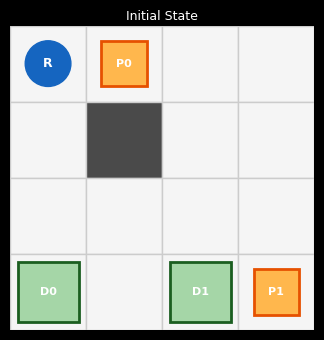

In [4]:
def draw_state(state: State, ax, title: str = '') -> None:
    ax.set_xlim(0, COLS)
    ax.set_ylim(ROWS, 0)   # row 0 at top
    ax.set_aspect('equal')

    # Grid cells
    for r in range(ROWS):
        for c in range(COLS):
            color = '#4a4a4a' if GRID[r, c] == 1 else '#f5f5f5'
            ax.add_patch(Rectangle((c, r), 1, 1, linewidth=1,
                                    edgecolor='#cccccc', facecolor=color, zorder=1))

    # Storage locations
    for pid, (r, c) in STORAGE_LOCATIONS.items():
        color = '#2e7d32' if state.delivered[pid] else '#a5d6a7'
        ax.add_patch(Rectangle((c + 0.1, r + 0.1), 0.8, 0.8,
                                linewidth=2, edgecolor='#1b5e20',
                                facecolor=color, zorder=2))
        ax.text(c + 0.5, r + 0.5, f'D{pid}',
                ha='center', va='center', fontsize=8,
                fontweight='bold', color='white', zorder=3)

    # Packages still in the warehouse (not carried, not delivered)
    for pid, (r, c) in PACKAGE_LOCATIONS.items():
        if not state.delivered[pid] and state.carrying != pid:
            ax.add_patch(Rectangle((c + 0.2, r + 0.2), 0.6, 0.6,
                                    linewidth=2, edgecolor='#e65100',
                                    facecolor='#ffb74d', zorder=2))
            ax.text(c + 0.5, r + 0.5, f'P{pid}',
                    ha='center', va='center', fontsize=8,
                    fontweight='bold', color='white', zorder=3)

    # Robot
    r, c = state.robot_pos
    ax.add_patch(Circle((c + 0.5, r + 0.5), 0.30, color='#1565c0', zorder=4))
    ax.text(c + 0.5, r + 0.5, 'R',
            ha='center', va='center', fontsize=9,
            fontweight='bold', color='white', zorder=5)

    # Small package indicator on robot if carrying
    if state.carrying is not None:
        ax.add_patch(Rectangle((c + 0.52, r + 0.12), 0.32, 0.32,
                                linewidth=1, edgecolor='white',
                                facecolor='#ffb74d', zorder=6))
        ax.text(c + 0.68, r + 0.28, str(state.carrying),
                ha='center', va='center', fontsize=6, color='white', zorder=7)

    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_title(title, fontsize=9, pad=4)


# Show the initial state
s0 = State(robot_pos=START_POS, carrying=None,
           delivered=tuple([False] * NUM_PACKAGES))

fig, ax = plt.subplots(figsize=(3.5, 3.5))
draw_state(s0, ax, title='Initial State')
plt.tight_layout()
plt.show()

---
## 3. Action Space  `A`

The robot has **6 possible actions** at every state:

| Action | Effect |
|--------|--------|
| `MOVE_UP` | Move one cell upward (row − 1) |
| `MOVE_DOWN` | Move one cell downward (row + 1) |
| `MOVE_LEFT` | Move one cell leftward (col − 1) |
| `MOVE_RIGHT` | Move one cell rightward (col + 1) |
| `PICKUP` | Pick up the package at the robot's current cell |
| `DELIVER` | Deliver the carried package at the robot's current cell |

**Constraints (checked inside the transition function):**
- Movement into an **obstacle or out-of-bounds** cell is rejected — robot stays in place
- `PICKUP` is only valid when the robot is **not carrying** anything **and** there is an
  undelivered package at the current position
- `DELIVER` is only valid when the robot **is carrying** package `i` **and** is at
  `STORAGE_LOCATIONS[i]`

In [5]:
class Action(Enum):
    MOVE_UP    = 'up'
    MOVE_DOWN  = 'down'
    MOVE_LEFT  = 'left'
    MOVE_RIGHT = 'right'
    PICKUP     = 'pickup'
    DELIVER    = 'deliver'

# Row/col deltas for the four movement actions
DELTAS = {
    Action.MOVE_UP:    (-1,  0),
    Action.MOVE_DOWN:  ( 1,  0),
    Action.MOVE_LEFT:  ( 0, -1),
    Action.MOVE_RIGHT: ( 0,  1),
}

print(f'|A| = {len(Action)} actions')
print()
for a in Action:
    delta = f'delta(r,c) = {DELTAS[a]}' if a in DELTAS else 'interaction'
    print(f'  {a.value:<12}  {delta}')

|A| = 6 actions

  up            delta(r,c) = (-1, 0)
  down          delta(r,c) = (1, 0)
  left          delta(r,c) = (0, -1)
  right         delta(r,c) = (0, 1)
  pickup        interaction
  deliver       interaction


---
## 4. Transition Function  `T(s, a) → s'`  and Reward  `R(s, a)`

Our environment is **deterministic**: each `(state, action)` pair produces exactly one next state.
The transition and reward are computed together in a single `step` function.

### Movement actions
```
target = robot_pos + delta(action)
if target is in-bounds and passable:
    robot_pos ← target          reward = STEP_COST
else:
    robot_pos unchanged          reward = WALL_PENALTY
```

### PICKUP
```
if not carrying  AND  there is an undelivered package at robot_pos:
    carrying ← package_id        reward = PICKUP_REWARD + STEP_COST
else:
    no change                    reward = INVALID_PENALTY
```

### DELIVER
```
if carrying package i  AND  robot_pos == STORAGE_LOCATIONS[i]:
    delivered[i] ← True
    carrying ← None              reward = DELIVERY_REWARD + STEP_COST
else:
    no change                    reward = INVALID_PENALTY
```

### Reward structure

| Event | Reward |
|-------|-------:|
| Every action (step cost) | −1 |
| Wall or obstacle collision | −5 |
| Invalid action | −10 |
| Successful pickup | +10 (net +9 with step cost) |
| Successful delivery | +100 (net +99 with step cost) |

In [ ]:
# ── Reward constants ───────────────────────────────────────────────────
STEP_COST       = -1
WALL_PENALTY    = -5
INVALID_PENALTY = -10
PICKUP_REWARD   = +10
DELIVERY_REWARD = +100


def step(state: State, action: Action) -> Tuple[State, float, bool]:
    """Apply *action* to *state*. Returns (next_state, reward, done)."""
    row, col  = state.robot_pos
    carrying  = state.carrying
    delivered = list(state.delivered)

    # ── Movement ──────────────────────────────────────────────────────
    if action in DELTAS:
        dr, dc = DELTAS[action]
        nr, nc = row + dr, col + dc

        if 0 <= nr < ROWS and 0 <= nc < COLS and GRID[nr, nc] == 0:
            new_pos = (nr, nc)
            reward  = STEP_COST
        else:
            new_pos = (row, col)   # blocked — stay in place
            reward  = WALL_PENALTY

        next_state = State(new_pos, carrying, tuple(delivered))

    # ── PICKUP ────────────────────────────────────────────────────────
    elif action == Action.PICKUP:
        valid = False
        if carrying is None:
            for pid, pkg_pos in PACKAGE_LOCATIONS.items():
                if (row, col) == pkg_pos and not delivered[pid]:
                    carrying = pid
                    valid    = True
                    break
        reward     = PICKUP_REWARD + STEP_COST if valid else INVALID_PENALTY
        next_state = State((row, col), carrying, tuple(delivered))

    # ── DELIVER ───────────────────────────────────────────────────────
    elif action == Action.DELIVER:
        valid = False
        if carrying is not None and (row, col) == STORAGE_LOCATIONS[carrying]:
            delivered[carrying] = True
            carrying            = None
            valid               = True
        reward     = DELIVERY_REWARD + STEP_COST if valid else INVALID_PENALTY
        next_state = State((row, col), carrying, tuple(delivered))

    else:
        raise ValueError(f'Unknown action: {action}')

    done = all(next_state.delivered)
    return next_state, reward, done


# ── Quick sanity check ─────────────────────────────────────────────────
s = State((0, 0), None, (False, False))
s, r, done = step(s, Action.MOVE_RIGHT)   # move to (0,1) where P0 is
print(f'After MOVE_RIGHT : {s}  reward={r}')
s, r, done = step(s, Action.PICKUP)       # pick up P0
print(f'After PICKUP     : {s}  reward={r}')
s, r, done = step(s, Action.DELIVER)      # wrong location — invalid
print(f'After DELIVER (invalid): {s}  reward={r}')

---
## 5. Terminal Condition

An **episode ends** as soon as all packages have been delivered:

```
done = all(state.delivered)   # True when every delivered[i] is True
```

- The step cost encourages the agent to complete deliveries as quickly as possible
- There is no explicit time limit in this formulation, but the cumulative step cost creates
  a natural pressure for efficiency

---

## MDP Summary

| Component | Definition |
|-----------|------------|
| **State** | `(robot_pos, carrying, delivered)` — 180 states for our 4×4, N=2 setting |
| **Actions** | 4 movement + PICKUP + DELIVER |
| **Transitions** | Deterministic; blocked moves leave position unchanged |
| **Rewards** | step −1 / wall −5 / invalid −10 / pickup +10 / delivery +100 |
| **Terminal** | `all(delivered)` — all packages successfully stored |

In [ ]:
def is_terminal(state: State) -> bool:
    return all(state.delivered)


class WarehouseMDP:
    """Minimal MDP wrapper — exposes reset / step / is_terminal."""

    def reset(self) -> State:
        return State(
            robot_pos=START_POS,
            carrying=None,
            delivered=tuple([False] * NUM_PACKAGES),
        )

    def step(self, state: State, action: Action) -> Tuple[State, float, bool]:
        return step(state, action)

    def is_terminal(self, state: State) -> bool:
        return is_terminal(state)

    @property
    def all_actions(self):
        return list(Action)


# Verify
mdp = WarehouseMDP()
s0  = mdp.reset()
print(f'Initial state  : {s0}')
print(f'Is terminal    : {mdp.is_terminal(s0)}')
print(f'Actions        : {[a.value for a in mdp.all_actions]}')

---
## 6. Example Trajectory

Let's manually walk through a complete episode to see the MDP in action.

**Plan:**
1. Move right → pick up **Package 0** at `(0, 1)`
2. Navigate down to `(3, 0)` — going around the obstacle at `(1, 1)` via column 0
3. Deliver **Package 0** at **Storage 0** `(3, 0)`
4. Move right along row 3 → pick up **Package 1** at `(3, 3)`
5. Move left one step → deliver **Package 1** at **Storage 1** `(3, 2)`

This is a hand-crafted (not optimal) trajectory.
A trained RL agent would discover a shorter or equally short path on its own.

In [ ]:
mdp   = WarehouseMDP()
state = mdp.reset()

plan = [
    (Action.MOVE_RIGHT, 'move to P0 at (0,1)'),
    (Action.PICKUP,     'pick up Package 0'),
    (Action.MOVE_LEFT,  'back to col 0'),
    (Action.MOVE_DOWN,  'row 0 → 1'),
    (Action.MOVE_DOWN,  'row 1 → 2'),
    (Action.MOVE_DOWN,  'row 2 → 3'),
    (Action.DELIVER,    'deliver P0 at D0 (3,0)'),
    (Action.MOVE_RIGHT, 'row 3: col 0 → 1'),
    (Action.MOVE_RIGHT, 'row 3: col 1 → 2'),
    (Action.MOVE_RIGHT, 'row 3: col 2 → 3 = P1'),
    (Action.PICKUP,     'pick up Package 1'),
    (Action.MOVE_LEFT,  'col 3 → 2 = D1'),
    (Action.DELIVER,    'deliver P1 at D1 (3,2)'),
]

trajectory   = [state]
total_reward = 0

hdr = f'{"Step":<5} {"Action":<14} {"Note":<28} {"Reward":>7}'
print(hdr)
print('-' * len(hdr))
print(f'{"0":<5} {"—":<14} {"start":<28} {"":>7}  {state}')

for step_num, (action, note) in enumerate(plan, start=1):
    next_state, reward, done = mdp.step(state, action)
    total_reward += reward
    print(f'{step_num:<5} {action.value:<14} {note:<28} {reward:>+7.0f}  {next_state}')
    trajectory.append(next_state)
    state = next_state
    if done:
        break

print('-' * len(hdr))
print(f'Total reward : {total_reward}')
print(f'Done         : {is_terminal(state)}')

In [ ]:
# Visualise five key states from the trajectory
key_indices = [0, 2, 7, 11, 13]
key_titles  = [
    'Step 0\nInitial',
    'Step 2\nPickup P0',
    'Step 7\nDeliver P0',
    'Step 11\nPickup P1',
    'Step 13\nAll delivered',
]

fig, axes = plt.subplots(1, 5, figsize=(14, 3.5))
for ax, idx, title in zip(axes, key_indices, key_titles):
    draw_state(trajectory[idx], ax, title=title)

plt.suptitle('Trajectory — Key States', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()